<a href="https://colab.research.google.com/github/nishasn10/Random_forest/blob/main/Random%20forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (4269, 13)

First 5 Rows:
   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_

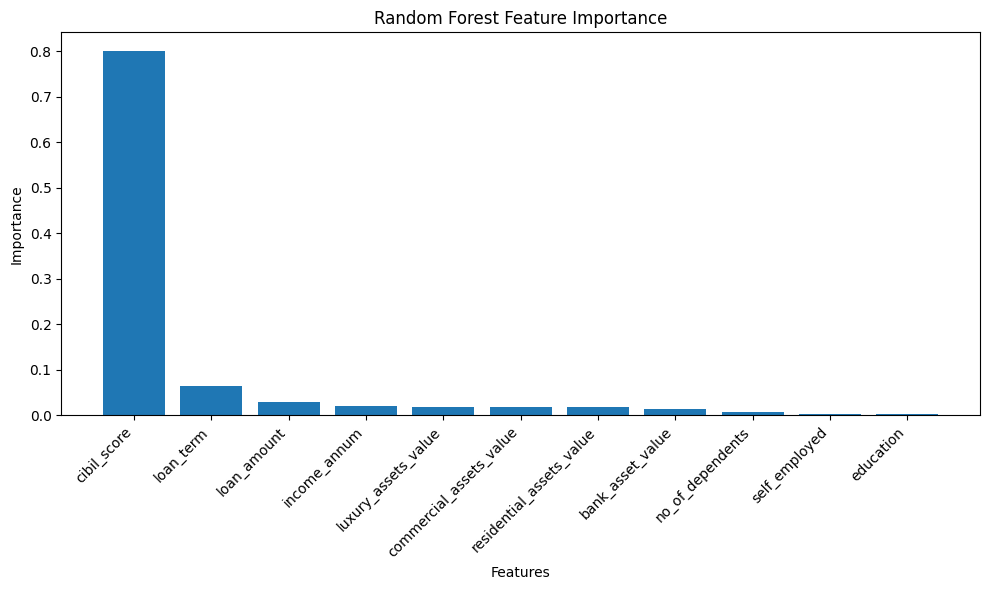

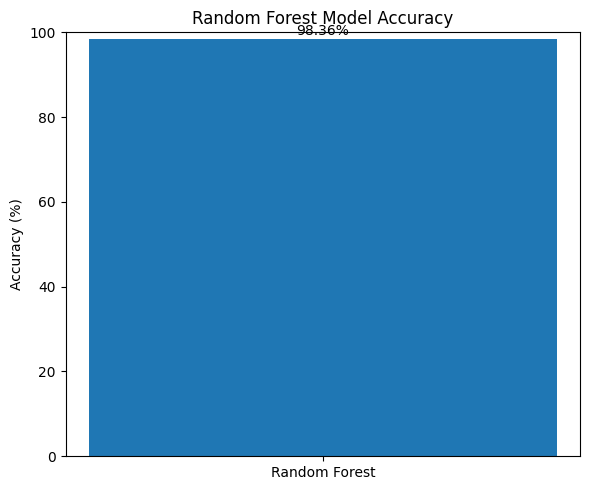

In [4]:
# ============================================
# RANDOM FOREST - LOAN APPROVAL PREDICTION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------

df = pd.read_csv("loan_approval_dataset.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# --------------------------------------------
# 2. Clean Column Names
# --------------------------------------------

df.columns = df.columns.str.strip()

print("\nColumn Names:")
print(df.columns)


# --------------------------------------------
# 3. Check Missing Values
# --------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# --------------------------------------------
# 4. Remove Extra Spaces from Categorical Data
# --------------------------------------------

df["education"] = df["education"].str.strip()
df["self_employed"] = df["self_employed"].str.strip()
df["loan_status"] = df["loan_status"].str.strip()


# --------------------------------------------
# 5. Encode Categorical Columns
# --------------------------------------------

encoder = LabelEncoder()

df["education"] = encoder.fit_transform(
    df["education"]
)

df["self_employed"] = encoder.fit_transform(
    df["self_employed"]
)

df["loan_status"] = encoder.fit_transform(
    df["loan_status"]
)


# --------------------------------------------
# 6. Separate Features and Target
# --------------------------------------------

X = df.drop(
    ["loan_id", "loan_status"],
    axis=1
)

y = df["loan_status"]


# --------------------------------------------
# 7. Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# --------------------------------------------
# 8. Create Random Forest Model
# --------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# --------------------------------------------
# 9. Train the Model
# --------------------------------------------

model.fit(
    X_train,
    y_train
)


# --------------------------------------------
# 10. Make Predictions
# --------------------------------------------

y_pred = model.predict(X_test)


# --------------------------------------------
# 11. Calculate Accuracy
# --------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================================")
print("RANDOM FOREST ACCURACY")
print("================================")

print(f"Accuracy: {accuracy * 100:.2f}%")


# --------------------------------------------
# 12. Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# --------------------------------------------
# 13. Classification Report
# --------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# --------------------------------------------
# 14. Feature Importance
# --------------------------------------------

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


# --------------------------------------------
# 15. Feature Importance Graph
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title(
    "Random Forest Feature Importance"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# --------------------------------------------
# 16. Accuracy Graph
# --------------------------------------------

plt.figure(figsize=(6, 5))

plt.bar(
    ["Random Forest"],
    [accuracy * 100]
)

plt.ylabel("Accuracy (%)")

plt.title(
    "Random Forest Model Accuracy"
)

plt.ylim(0, 100)

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.tight_layout()

plt.show()